In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.special import sici
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

plt.rcParams.update({
    'font.size': 10,          # base font size
    'axes.labelsize': 10,     # axis label size
    'axes.titlesize': 10,     # title size
    'xtick.labelsize': 9,     
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


----
Plots of analytical solutions with varying $\gamma$, from Ennio notebook

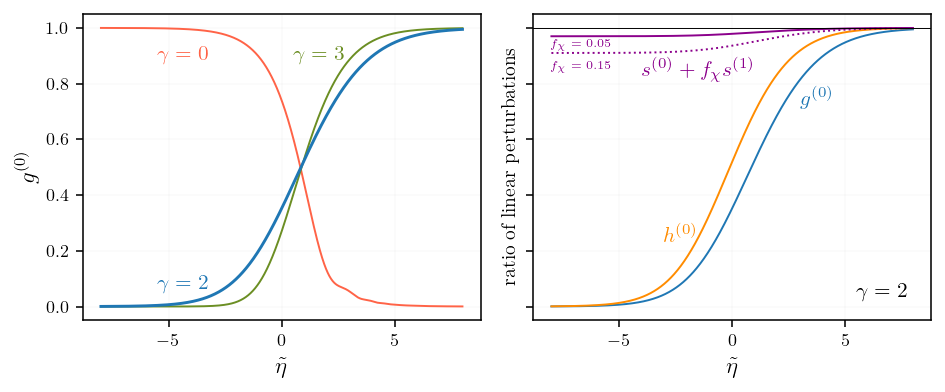

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(6.85, 2.9), sharey=True, dpi=140)

etavals, g_gamma0, g_gamma3, g_gamma2 = np.loadtxt('/home/fverdian/class/soundspeed-scripts/plots4paper/g0_gammasData.dat', unpack=True)

# Left plot - varying gamma
axs[0].plot(etavals, g_gamma0, lw=1., c='tomato')
axs[0].text(-5.5,0.9, r'$\gamma=0$', color='tomato', fontsize=11, ha='left', va='center', rotation=0)

axs[0].plot(etavals, g_gamma3, lw=1., c='olivedrab')
axs[0].text(0.5,0.9, r'$\gamma=3$', color='olivedrab', fontsize=11, ha='left', va='center', rotation=0)

axs[0].plot(etavals, g_gamma2, lw=1.5, c='tab:blue')
axs[0].text(-5.5,0.08, r'$\gamma=2$', color='tab:blue', fontsize=11, ha='left', va='center', rotation=0)

axs[0].set_xlabel(r'$\tilde\eta$', fontsize=12)
axs[0].set_ylabel(r'$g^{(0)}$', fontsize=12)
axs[0].grid(lw=0.05)

# Right plot - transfer functions
etavals, h0, s1_fx0p15, s1_fx0p05, g0 = np.loadtxt('/home/fverdian/class/soundspeed-scripts/plots4paper/tf_gamma2Data.dat', unpack=True)

axs[1].plot(etavals, g0, lw=1., c='tab:blue')
axs[1].text(3,0.75, r'$g^{(0)}$', color='tab:blue', fontsize=11, va='center', rotation=0)

axs[1].plot(etavals, h0, lw=1., c='darkorange')
axs[1].text(-3.,0.25, r'$h^{(0)}$', color='darkorange', fontsize=11, va='center', rotation=0)

axs[1].plot(etavals, s1_fx0p05, lw=1., c='darkmagenta')
axs[1].text(-8,0.94, r'$f_\chi = 0.05$', color='darkmagenta', fontsize=6, ha='left', va='center', rotation=0)

axs[1].plot(etavals, s1_fx0p15, lw=1., ls=':', c='darkmagenta')
axs[1].text(-8,0.86, r'$f_\chi = 0.15$', color='darkmagenta', fontsize=6., ha='left', va='center', rotation=0)

axs[1].text(-4.,0.85, r'$s^{(0)}+f_\chi s^{(1)}$', color='darkmagenta', fontsize=11, va='center', rotation=0)

axs[1].text(5.5,0.05, r'$\gamma=2$', color='k', fontsize=11, va='center', rotation=0)

axs[1].axhline(1., lw=0.5,c='k')

axs[1].set_xlabel(r'$\tilde\eta$', fontsize=12)
axs[1].set_ylabel(r'ratio of linear perturbations')
axs[1].grid(lw=0.05)

plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/g0_gammas_tf_gamma2_py.pdf', bbox_inches='tight')

plt.show()

---
Figura 2

In [2]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {'omega_b': 0.0223828, 'h': h, 'z_reio': 7.6711, 'YHe': 0.25, 'perturbations_verbose': 1, 'background_verbose': 3, 'output': 'mTk, vTk, mPk', 'P_k_max_1/Mpc': 10, 'z_max_pk': 1000, 'format': 'class'}

chiCDM = Class()
chiCDM.set(common_settings)
m_ev = 1.e-27
fx = 0.1
chiCDM.set({'omega_cdm': 0.12, 'scf_potential': 'axion', 'n_axion': 1, 'f_axion': 0.4, 'Omega_scf': ((fx/(1-fx))*(0.12+0.02238))/h/h, 'm_axion': m_ev * _ev_to_HO_, 'tol_shooting_deltax': 1e-4, 'tol_shooting_deltaF': 1e-4, 'scf_parameters': '0.05,0.0', 'scf_tuning_index': 0, 'scf_evolve_as_fluid': 'yes', 'scf_evolve_like_axionCAMB': 'yes', 'threshold_scf_fluid_m_over_H': 3, 'do_shooting': 'yes', 'do_shooting_scf': 'yes', 'scf_has_perturbations': 'yes', 'use_big_theta_scf': 'no', 'use_delta_scf_over_1plusw': 'no', 'attractor_ic_scf': 'no', 'evolver': 0})
chiCDM.compute()

pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({'N_ur': 3.046, 'omega_cdm':0.12,})
pureCDM.compute()

nuCDM = Class()
nuCDM.set(common_settings)
mnu= 1.
# Fix omega_m = 0.142
omega_nu = mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368998 Gyr
 -> conformal age = 13577.281529 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.0344047, wished 0.0344048
Additional scf parameters used: 
n = 1.000000e+00 m_a = 9.974627e-28 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 6.181851e-01 	 phi_ini = 2.472740e-01 
     -> Exact log10(z_c) = 1.046375e+00 	 f_ede = 9.957235e-02 log10 f_ede = -1.001861e+00
     -> phi(z_c) = 1.396687e-01 
     -> Omega_Lambda = 0.655855, wished 0.655855
 -> radiation/matter equality at z = 3781.414959
    corresponding to conformal time = 102.229871 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972    

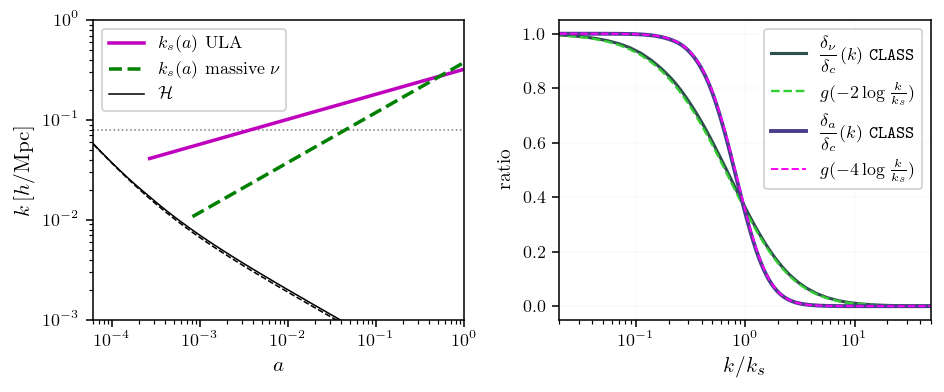

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(6.85, 2.9),dpi=140)

# Left plot - k_s evolution
background = chiCDM.get_background()
a = 1/(background['z']+1)
Ha = background['H [1/Mpc]']/(1.+background['z'])
Ha_chi_int = interp1d(a, Ha)

background = nuCDM.get_background()
a_nu = 1/(background['z']+1)
Ha_nu_cosmo = background['H [1/Mpc]']/(1.+background['z'])

axs[0].axhline(0.08, lw=0.8, color='gray', ls=':')

kJ_ULA_z = interp1d(a, 8.4e12 * pow(m_ev/h, 1/2) * (a)**0.25)
a_ma = 2.38e-4
a_eq = 1/(1+3781)
axs[0].loglog(a[a>a_eq], kJ_ULA_z(a)[a>a_eq], 'm', label=r'$k_s(a)$ ULA', lw=1.8)

kJnu_a = interp1d(a, np.sqrt(5/9)* 5.e-2 * (1./0.1) * pow(a, 1/2)* np.sqrt(nuCDM.Omega0_m()/0.3))
aNR_nu = 8.12e-04
axs[0].loglog(a[a>aNR_nu], kJnu_a(a)[a>aNR_nu], 'g', label=r'$k_s(a)$ massive $\nu$', lw=1.8, ls='--')
axs[0].loglog(a, Ha/h, 'k', label=r'$\mathcal{H}$', lw=0.8)
axs[0].loglog(a_nu, Ha_nu_cosmo/h, 'k--', lw=0.8)

axs[0].set_xlim([6.e-5, 1])
axs[0].set_ylim([1.e-3, 1])
axs[0].legend()
axs[0].set_xlabel(r'$a$', fontsize=11)
axs[0].set_ylabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=11)

# Right plot - transfer function comparison
zeval = 0.5

def g_an(t):
    return 1 + 6 * np.exp(-t) * np.cos(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[1] - 3 * np.exp(-t) * np.pi * np.sin(np.sqrt(6) * np.exp(-t / 2)) + 6 * np.exp(-t) * np.sin(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[0]

chi_tk_k = chiCDM.get_transfer(z=zeval)
kEval = chi_tk_k['k (h/Mpc)']
T_ratio_ax = chi_tk_k['d_scf']/ chi_tk_k['d_cdm']
kJa = 8.4e12 * pow(m_ev/h, 1/2) * (1/(1+zeval))**0.25

nu_tk_k = nuCDM.get_transfer(z=zeval)
T_ratio_nu = nu_tk_k['d_ncdm[0]']/ nu_tk_k['d_cdm']
kJnu = np.sqrt(5/9)* 5.e-2 * (mnu/0.1) * pow((1/(1+zeval)), 1/2)* np.sqrt(nuCDM.Omega0_m()/0.3)

axs[1].plot(kEval/kJnu, T_ratio_nu, 'darkslategray', linewidth=1.6, label=r'$\displaystyle\frac{\delta_\nu}{\delta_c}(k)$ $\texttt{CLASS}$')
axs[1].plot(kEval/kJnu, g_an(-2*np.log(kEval/(kJnu))), 'limegreen', linestyle='--', linewidth=1.2, label=r'$g(-2\log \frac{k}{k_s})$ ')
axs[1].plot(kEval/kJa, T_ratio_ax, 'darkslateblue', linewidth=2., label=r'$\displaystyle\frac{\delta_a}{\delta_c}(k)$ $\texttt{CLASS}$')
axs[1].plot(kEval/kJa, g_an(-4*np.log(kEval/(kJa))), 'fuchsia', linestyle='--', linewidth=1., label=r'$g(-4\log \frac{k}{k_s})$')

axs[1].set_xscale('log')
axs[1].set_xlabel(r'$k/k_s$', fontsize=11)
axs[1].legend(loc='best')
axs[1].set_xlim([2.e-2, 5.e1])
axs[1].set_ylabel(r'ratio')
axs[1].grid(lw=0.05)

plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/ksEvolution_lincompare.pdf', bbox_inches='tight')
plt.show()

---
Figura 3

In [4]:
kk = np.logspace(-3,np.log10(5),200)
chiCDM.set({
    'm_axion': 1.e-20 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()

Pk_cdm = np.array([chiCDM.pk_lin(k*h,zeval)*h**3 for k in kk])

chiCDM.set({
    'm_axion': 1.e-27 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()
Pk_ax = np.array([chiCDM.pk_lin(k*h,zeval)*h**3 for k in kk])


Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368997 Gyr
 -> conformal age = 13576.578688 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
    Scalar field details:
     -> Omega_scf = 0.0344047, wished 0.0344048
Additional scf parameters used: 
n = 1.000000e+00 m_a = 9.974627e-21 eV, f_a/mpl = 4.000000e-01
     -> theta_ini = 1.325642e-02 	 phi_ini = 5.302569e-03 
     -> Exact log10(z_c) = 1.046375e+00 	 f_ede = 9.957242e-02 log10 f_ede = -1.001861e+00
     -> phi(z_c) = 3.197946e-03 
     -> Omega_Lambda = 0.655855, wished 0.655855
 -> radiation/matter equality at z = 3781.415182
    corresponding to conformal time = 101.527424 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972    

In [5]:
kk2 = np.logspace(-3,np.log10(5),200)

mnu= 1.
nuCDM = Class()
nuCDM.set(common_settings)
# Fix omega_m = 0.142
omega_nu = mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

Pk_nu = np.array([nuCDM.pk_lin(k*h,zeval)*h**3 for k in kk2])
nuCDM = Class()
nuCDM.set(common_settings)
nuCDM.set({
    'omega_cdm':0.12,
    'N_ur': 2.0328,

})
nuCDM.compute()
Pk_nu_LCDM = np.array([nuCDM.pk_lin(k*h,zeval)*h**3 for k in kk2])


Running CLASS version v3.2.0
Computing background
 fraction of ncdm is 9.860216e-02 
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314329e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 1.000000e+00 eV (so m_i / omega_i =9.314329e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
Chose ndf15 as generic_evolver
 -> age = 13.784589 Gyr
 -> conformal age = 14182.057004 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.046 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3336.658707
    corresponding to conformal time = 115.787165 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0

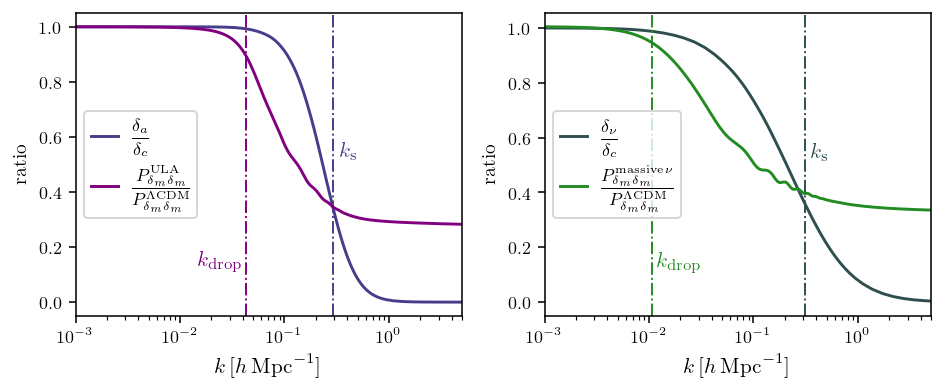

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(6.85, 2.9), dpi=140)

# Left plot - ULAs
chi_tk_k = chiCDM.get_transfer(z=zeval)

kEval=chi_tk_k['k (h/Mpc)']
d_ax_k=-chi_tk_k['d_scf']
d_cdm_k=-chi_tk_k['d_cdm']
T_ratio_ax =chi_tk_k['d_scf']/ chi_tk_k['d_cdm']

kJest =8.4e12 * pow(1.e-27/h,1/2) * (1/(1+zeval))**0.25
kdropest =5.2e-2 * pow(1.e-27*_ev_to_HO_/1.e6,1/2)
axs[0].axvline(kJest, linewidth=1., color='darkslateblue', linestyle='-.')
axs[0].text(kJest+5.e-2, 0.55, r'$k_\mathrm{s}$', color='darkslateblue', fontsize=11, ha='left', va='center', rotation=0)
axs[0].semilogx(kEval, chi_tk_k['d_scf']/chi_tk_k['d_cdm'],'darkslateblue',label=r'$\displaystyle\frac{\delta_a}{\delta_c}$')

axs[0].axvline(kdropest, linewidth=1., color='purple', linestyle='-.')
axs[0].text(1.5e-2, 0.15, r'$k_\mathrm{drop}$', color='purple', fontsize=11, ha='left', va='center', rotation=0)
axs[0].semilogx(kk, Pk_ax/Pk_cdm, 'purple', label=r'$\displaystyle\frac{P_{\delta_m \delta_m}^{\mathrm{ULA}}}{P_{\delta_m \delta_m}^{\mathrm{\Lambda CDM}}}$')

axs[0].set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$', fontsize=11)
axs[0].legend(loc='center left',handlelength=1.5)
axs[0].set_xlim([1.e-3,5])
axs[0].set_ylabel(r'ratio')

# Right plot - neutrinos
axs[1].plot(kEval, T_ratio_nu,'darkslategray', label=r'$\displaystyle\frac{\delta_\nu}{\delta_c}$')
axs[1].semilogx(kk2, Pk_nu/Pk_nu_LCDM, 'forestgreen', label=r'$\displaystyle\frac{P_{\delta_m \delta_m}^{\mathrm{massive}\,\nu}}{P_{\delta_m \delta_m}^{\mathrm{\Lambda CDM}}}$')

axs[1].axvline(kJnu, linewidth=1., color='darkslategray', linestyle='-.')
axs[1].text(kJnu+5.e-2, 0.55, r'$k_\mathrm{s}$', color='darkslategray', fontsize=11, ha='left', va='center', rotation=0)

kdropnu = 0.0107753
axs[1].axvline(kdropnu, linewidth=1., color='forestgreen', linestyle='-.')
axs[1].text(1.2e-2, 0.15, r'$k_\mathrm{drop}$', color='forestgreen', fontsize=11, ha='left', va='center', rotation=0)

axs[1].set_xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$', fontsize=11)
axs[1].legend(loc='center left',handlelength=1.5)
axs[1].set_xlim([1.e-3,5])
axs[1].set_ylabel(r'ratio')

plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/kdrop_vs_ks_ULA_nu.pdf', bbox_inches='tight')

plt.show()